# D11 Calculation Pathway Effects

Analyze how `D11` changes across calculation pathways while holding the observed ECTP slab fixed. 

In [1]:
import math
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from notebook_utils import (
    create_ectp_slabs,
    extract_d11,
    finite_percentile,
    finite_positive,
    hess_rcparams,
    load_pits,
    pathway_key,
    prepare_spread_rank_table,
    slab_attribute_record,
)
from paper_figure_utils import (
    build_d11_faceted_paired_ratio_figure,
    build_d11_quantile_slab_uncertainty_figure,
    build_d11_spread_attribute_correlations_figure,
    format_method_path,
    save_paper_figure,
    sort_pathways_by_emod_group,
    EMOD_METHOD_ORDER,
)
from snowpyt_mechparams.execution import ExecutionEngine
from snowpyt_mechparams.execution.config import ExecutionConfig
from snowpyt_mechparams.graph import default_graph
from snowpyt_mechparams.pathway import find_parameterizations

hess_rcparams()

TOP_N = 16

## Load Data and Enumerate D11 Pathways

Use the same ECTP slab definition as the slab-weight input analysis: Slab is the set of layers above the ECTP layer of propagation

In [2]:
pits = load_pits()
ectp_slabs = create_ectp_slabs(pits)
total_slabs = len(ectp_slabs)

pathways = find_parameterizations(default_graph, default_graph.get_node('D11'))
engine = ExecutionEngine()
config = ExecutionConfig(include_method_uncertainty=False) # input uncertainty only

print(f'Loaded {len(pits):,} pits and {total_slabs:,} ECTP slabs')
print(f'D11 pathways: {len(pathways)}')

Loaded 50,278 pits and 14,776 ECTP slabs
D11 pathways: 32


## Execute D11 Pathways

Store one row per slab-pathway attempt. Failed attempts remain in `d11_results` with `NaN` values so coverage can be computed directly from the same table.

In [3]:
records = []

for slab_index, slab in enumerate(ectp_slabs):
    slab_attrs = slab_attribute_record(slab_index, slab)
    results = engine.execute_all(slab, 'D11', config=config, pathways=pathways)

    for pathway_result in results.pathways.values():
        methods = pathway_result.methods_used
        d11_nominal, d11_std = extract_d11(pathway_result)
        d11_success = finite_positive(d11_nominal)

        records.append(
            {
                **slab_attrs,
                'pathway': pathway_key(methods),
                'pathway_description': pathway_result.pathway_description,
                'density_method': methods.get('density', 'data_flow'),
                'emod_method': methods.get('elastic_modulus', 'unknown'),
                'nu_method': methods.get('poissons_ratio', 'unknown'),
                'pathway_result_success': pathway_result.success,
                'success': d11_success,
                'D11_nominal': d11_nominal if d11_success else math.nan,
                'D11_std': d11_std if d11_success else math.nan,
                'D11_rel_uncertainty': d11_std / abs(d11_nominal) if d11_success else math.nan,
            }
        )

d11_results = pd.DataFrame(records)
d11_success = d11_results[d11_results['success']].copy()

print(f'Pathway attempts: {len(d11_results):,}')
print(f'Successful D11 calculations: {len(d11_success):,}')
print(f'Slabs with at least one successful D11 value: {d11_success["slab_index"].nunique():,}')
#d11_results.head()

Pathway attempts: 472,832
Successful D11 calculations: 8,858
Slabs with at least one successful D11 value: 823


## Top 8 Coverage Pathways

Rank pathways by successful ECTP slab coverage. 

In [4]:
pathway_coverage = (
    d11_results.groupby(['pathway', 'density_method', 'emod_method', 'nu_method'])
    .agg(
        successful_slabs=('success', 'sum'),
        attempted_slabs=('success', 'count'),
    )
    .reset_index()
    .sort_values(['successful_slabs', 'pathway'], ascending=[False, True])
)
pathway_coverage['coverage_percent'] = 100.0 * pathway_coverage['successful_slabs'] / total_slabs

top_pathways = pathway_coverage.head(TOP_N)['pathway'].tolist()
coverage_table = pd.DataFrame(
    {
        'Pathway': [format_method_path(*pathway.split(' -> ')) for pathway in top_pathways],
        'Successful slabs': pathway_coverage.head(TOP_N)['successful_slabs'].map(lambda value: f'{int(value):,}'),
        'Coverage (%)': pathway_coverage.head(TOP_N)['coverage_percent'].map(lambda value: f'{value:.1f}'),
    }
)

coverage_table

# Update index to be ranking
coverage_table.index = coverage_table.index.get_indexer(coverage_table.index)
coverage_table.index.name = 'Rank'
coverage_table


,Pathway,Successful slabs,Coverage (%)
Rank,,,
0,Kim and Jamieson (2014) Table 2 -> Schöttner e...,743,5.0
1,Kim and Jamieson (2014) Table 2 -> Wautier et ...,743,5.0
2,Geldsetzer and Jamieson (2000) -> Schöttner et...,740,5.0
3,Geldsetzer and Jamieson (2000) -> Wautier et a...,740,5.0
4,Geldsetzer and Jamieson (2000) -> Köchle and S...,733,5.0
5,Kim and Jamieson (2014) Table 2 -> Köchle and ...,634,4.3
6,Kim and Jamieson (2014) Table 2 -> Bergfeld et...,498,3.4
7,Geldsetzer and Jamieson (2000) -> Bergfeld et ...,475,3.2
8,Geldsetzer and Jamieson (2000) -> Schöttner et...,449,3.0


## Top-8 Slab Subset

Keep only slabs where all top-8 pathways produced finite, positive D11 values.

In [5]:
top8_success = d11_success[d11_success['pathway'].isin(top_pathways)].copy()
common_counts = top8_success.groupby('slab_index')['pathway'].nunique()
common_slab_indices = common_counts[common_counts == TOP_N].index

d11_common = top8_success[top8_success['slab_index'].isin(common_slab_indices)].copy()
d11_common['pathway'] = pd.Categorical(d11_common['pathway'], categories=top_pathways, ordered=True)
d11_common = d11_common.sort_values(['pathway', 'slab_index'])

d11_wide = d11_common.pivot(
    index=['slab_index', 'slab_id', 'pit_id'],
    columns='pathway',
    values='D11_nominal',
).reindex(columns=top_pathways)

print(f'Top-8 pathways: {TOP_N}')
print(f'Slabs successful for all top-8 pathways: {len(common_slab_indices):,}')

d11_wide.head()


Top-8 pathways: 16
Slabs successful for all top-8 pathways: 317


,,pathway,kim_jamieson_table2 -> schottner -> kochle,kim_jamieson_table2 -> wautier -> kochle,geldsetzer -> schottner -> kochle,geldsetzer -> wautier -> kochle,geldsetzer -> kochle -> kochle,kim_jamieson_table2 -> kochle -> kochle,kim_jamieson_table2 -> bergfeld -> kochle,geldsetzer -> bergfeld -> kochle,geldsetzer -> schottner -> srivastava,geldsetzer -> wautier -> srivastava,kim_jamieson_table2 -> schottner -> srivastava,kim_jamieson_table2 -> wautier -> srivastava,kim_jamieson_table2 -> bergfeld -> srivastava,geldsetzer -> kochle -> srivastava,kim_jamieson_table2 -> kochle -> srivastava,geldsetzer -> bergfeld -> srivastava
slab_index,slab_id,pit_id,,,,,,,,,,,,,,,,
98,1036_slab_0,1036,1.033784e+05,3.897811e+06,9.853946e+04,3.803908e+06,1.058172e+06,1.171239e+06,2.183333e+05,2.085478e+05,9.927990e+04,3.832491e+06,1.041552e+05,3.927100e+06,2.199739e+05,1.066123e+06,1.180040e+06,2.101149e+05
141,1057_slab_0,1057,3.364213e+07,1.037104e+09,3.518988e+07,1.061108e+09,2.822266e+08,2.740997e+08,6.979665e+07,7.286510e+07,3.545430e+07,1.069081e+09,3.389492e+07,1.044897e+09,7.032111e+07,2.843473e+08,2.761593e+08,7.341262e+07
142,1057_slab_1,1057,3.364213e+07,1.037104e+09,3.518988e+07,1.061108e+09,2.822266e+08,2.740997e+08,6.979665e+07,7.286510e+07,3.545430e+07,1.069081e+09,3.389492e+07,1.044897e+09,7.032111e+07,2.843473e+08,2.761593e+08,7.341262e+07
143,1057_slab_2,1057,3.364213e+07,1.037104e+09,3.518988e+07,1.061108e+09,2.822266e+08,2.740997e+08,6.979665e+07,7.286510e+07,3.545430e+07,1.069081e+09,3.389492e+07,1.044897e+09,7.032111e+07,2.843473e+08,2.761593e+08,7.341262e+07
144,1057_slab_3,1057,3.364213e+07,1.037104e+09,3.518988e+07,1.061108e+09,2.822266e+08,2.740997e+08,6.979665e+07,7.286510e+07,3.545430e+07,1.069081e+09,3.389492e+07,1.044897e+09,7.032111e+07,2.843473e+08,2.761593e+08,7.341262e+07


## Paired Pathway Analysis

For each slab, compute the median D11 across all its successful pathways and express each pathway's D11 as a ratio to that median. This isolates the pathway effect from slab-to-slab variation.

Also compute spread metrics (max/min D11 ratio per slab) and select 3 representative slabs at quantiles of the spread distribution.

In [6]:
# --- Paired ratios ---
slab_medians = (
    d11_common.groupby('slab_index')['D11_nominal']
    .median()
    .rename('slab_median')
)
paired_effects = d11_common.merge(slab_medians, on='slab_index')
paired_effects['pathway_ratio'] = (
    paired_effects['D11_nominal'] / paired_effects['slab_median']
)

print(f'Paired effects rows: {len(paired_effects):,}')
print(f'Unique slabs: {paired_effects["slab_index"].nunique():,}')

# --- Spread metrics per slab ---
slab_spread_df = pd.DataFrame({
    'slab_index': d11_wide.index.get_level_values('slab_index'),
    'slab_id': d11_wide.index.get_level_values('slab_id'),
    'pit_id': d11_wide.index.get_level_values('pit_id'),
    'D11_min': d11_wide.min(axis=1).values,
    'D11_max': d11_wide.max(axis=1).values,
    'spread_ratio': (d11_wide.max(axis=1) / d11_wide.min(axis=1)).values,
    'min_pathway': d11_wide.idxmin(axis=1).values,
    'max_pathway': d11_wide.idxmax(axis=1).values,
})

print(f'\nSpread ratio summary:')
print(slab_spread_df['spread_ratio'].describe())

# --- Select 3 slabs at spread quantiles ---
quantiles = [0.30, 0.60, 0.90]
selected_rows = []
for q in quantiles:
    target = slab_spread_df['spread_ratio'].quantile(q)
    idx = (slab_spread_df['spread_ratio'] - target).abs().idxmin()
    selected_rows.append(slab_spread_df.loc[idx])

selected_slab_df = pd.DataFrame(selected_rows).reset_index(drop=True)
selected_slab_attrs = (
    d11_common[
        ['slab_index', 'n_layers', 'total_thickness_cm', 'grain_form_label']
    ]
    .drop_duplicates('slab_index')
)
selected_slab_df = selected_slab_df.merge(
    selected_slab_attrs,
    on='slab_index',
    how='left',
)
selected_slab_indices = selected_slab_df['slab_index'].tolist()
def _selected_slab_metadata_label(row):
    n_layers = int(row.n_layers)
    layer_label = 'layer' if n_layers == 1 else 'layers'
    grain_label = row.grain_form_label if pd.notna(row.grain_form_label) else 'unknown grain form'
    return f'{n_layers} {layer_label}, H={row.total_thickness_cm:.0f} cm, grain={grain_label}'

selected_slab_metadata_labels = [
    _selected_slab_metadata_label(row)
    for row in selected_slab_df.itertuples()
]
quantile_labels = [
    f'Pit {row.pit_id} (P{int(q * 100)} spread quantile, spread={row.spread_ratio:.1f})'
    for q, row in zip(quantiles, selected_slab_df.itertuples())
]

print('\nSelected slabs at spread quantiles:')
selected_slab_df[['pit_id', 'n_layers', 'total_thickness_cm', 'grain_form_label', 'spread_ratio', 'D11_min', 'D11_max']]

Paired effects rows: 5,072
Unique slabs: 317

Spread ratio summary:
count    317.000000
mean      40.303648
std       13.013518
min       25.698825
25%       31.778037
50%       31.778037
75%       51.611392
max       62.966211
Name: spread_ratio, dtype: float64

Selected slabs at spread quantiles:


,pit_id,n_layers,total_thickness_cm,grain_form_label,spread_ratio,D11_min,D11_max
0,1057,1,30.0,RGwp,31.778037,3.364213e+07,1.069081e+09
1,50003,2,93.0,"RGwp, RGsr",35.905804,6.918432e+08,2.484119e+10
2,14909,1,21.0,RGwp,62.966211,3.026027e+06,1.905374e+08


## Figure A: Faceted Paired-Ratio Plot

4-panel box plot of within-slab D11 ratios, grouped by Young's-modulus method. Each panel shows one Young's-modulus method with density and Poisson's ratio variants as rows.

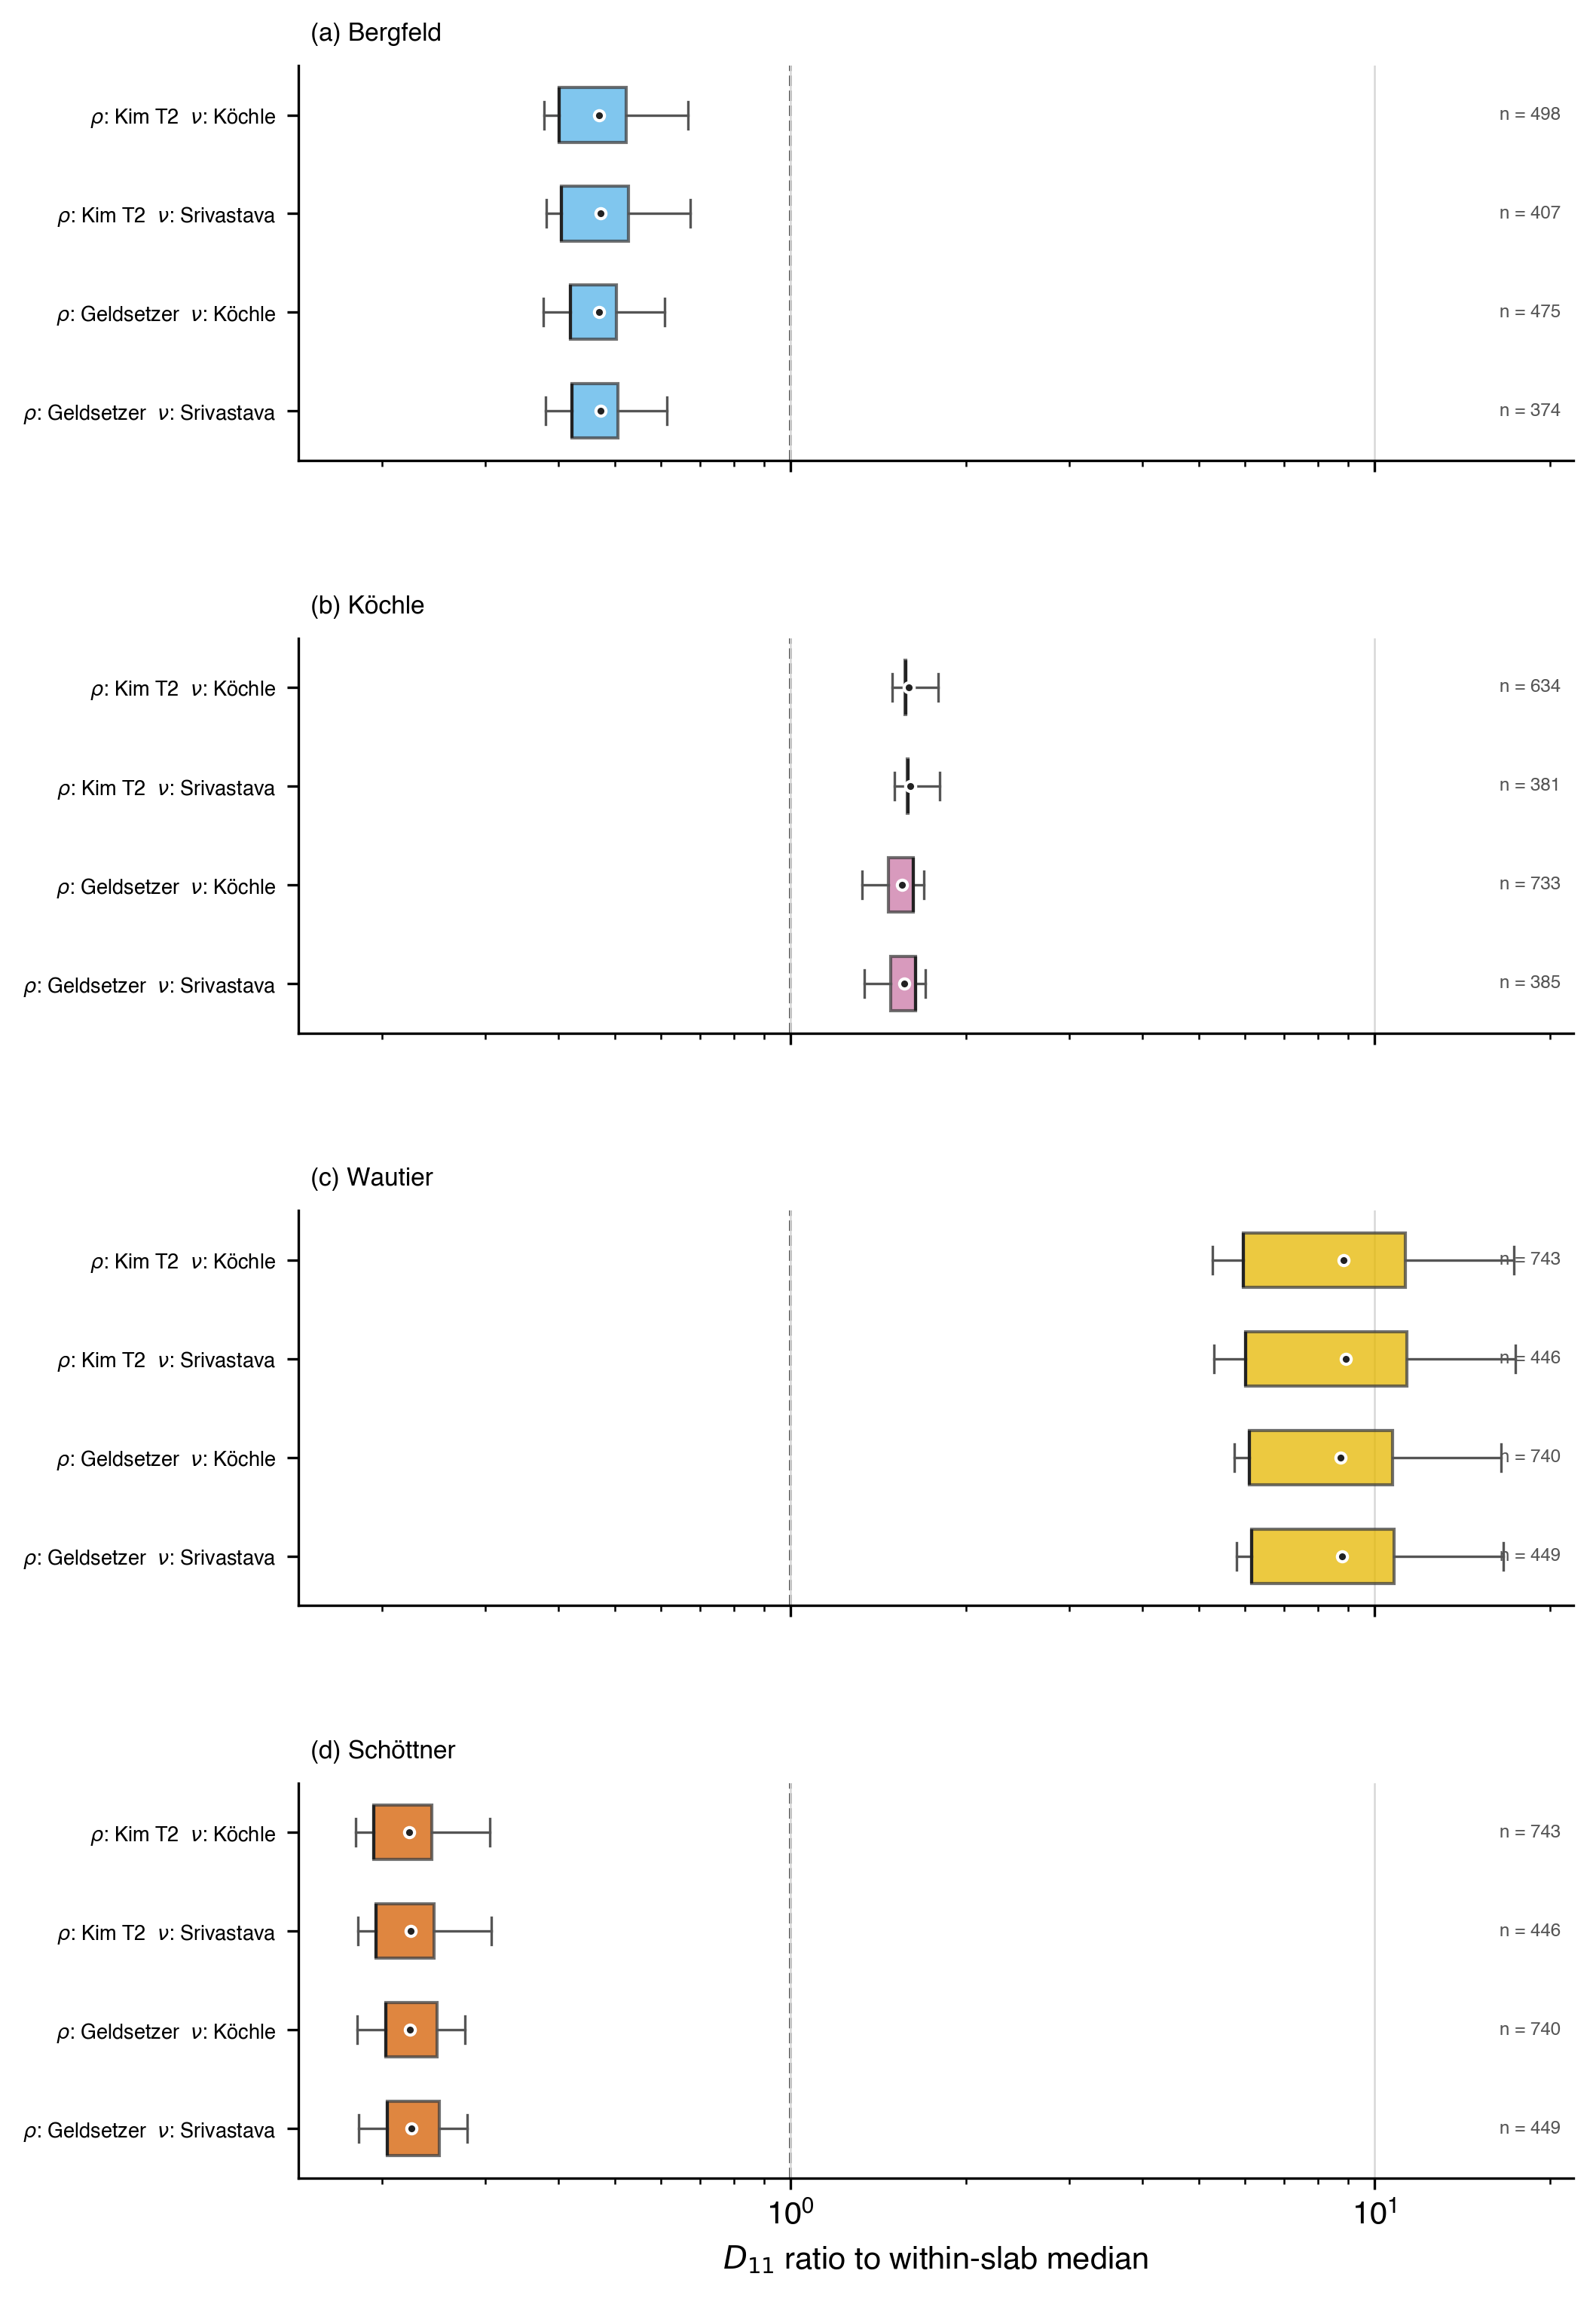

In [7]:
sorted_paths = sort_pathways_by_emod_group(top_pathways)

# Build pathway -> total successful slabs lookup from the full (unfiltered) coverage table
coverage_lookup = dict(
    zip(pathway_coverage['pathway'], pathway_coverage['successful_slabs'].astype(int))
)

fig_a = build_d11_faceted_paired_ratio_figure(
    paired_effects, sorted_paths, pathway_coverage=coverage_lookup
)
save_paper_figure(fig_a, 'd11_paired_pathway_effects')
plt.show()

## Figure C: Quantile-Selected Slab Uncertainty

D11 values and propagated input-measurement uncertainty for 3 slabs selected at the 30th, 60th, and 90th percentiles of the max/min D11 spread ratio distribution. Points are colored by Young's-modulus method; error bars show propagated input-measurement uncertainty.

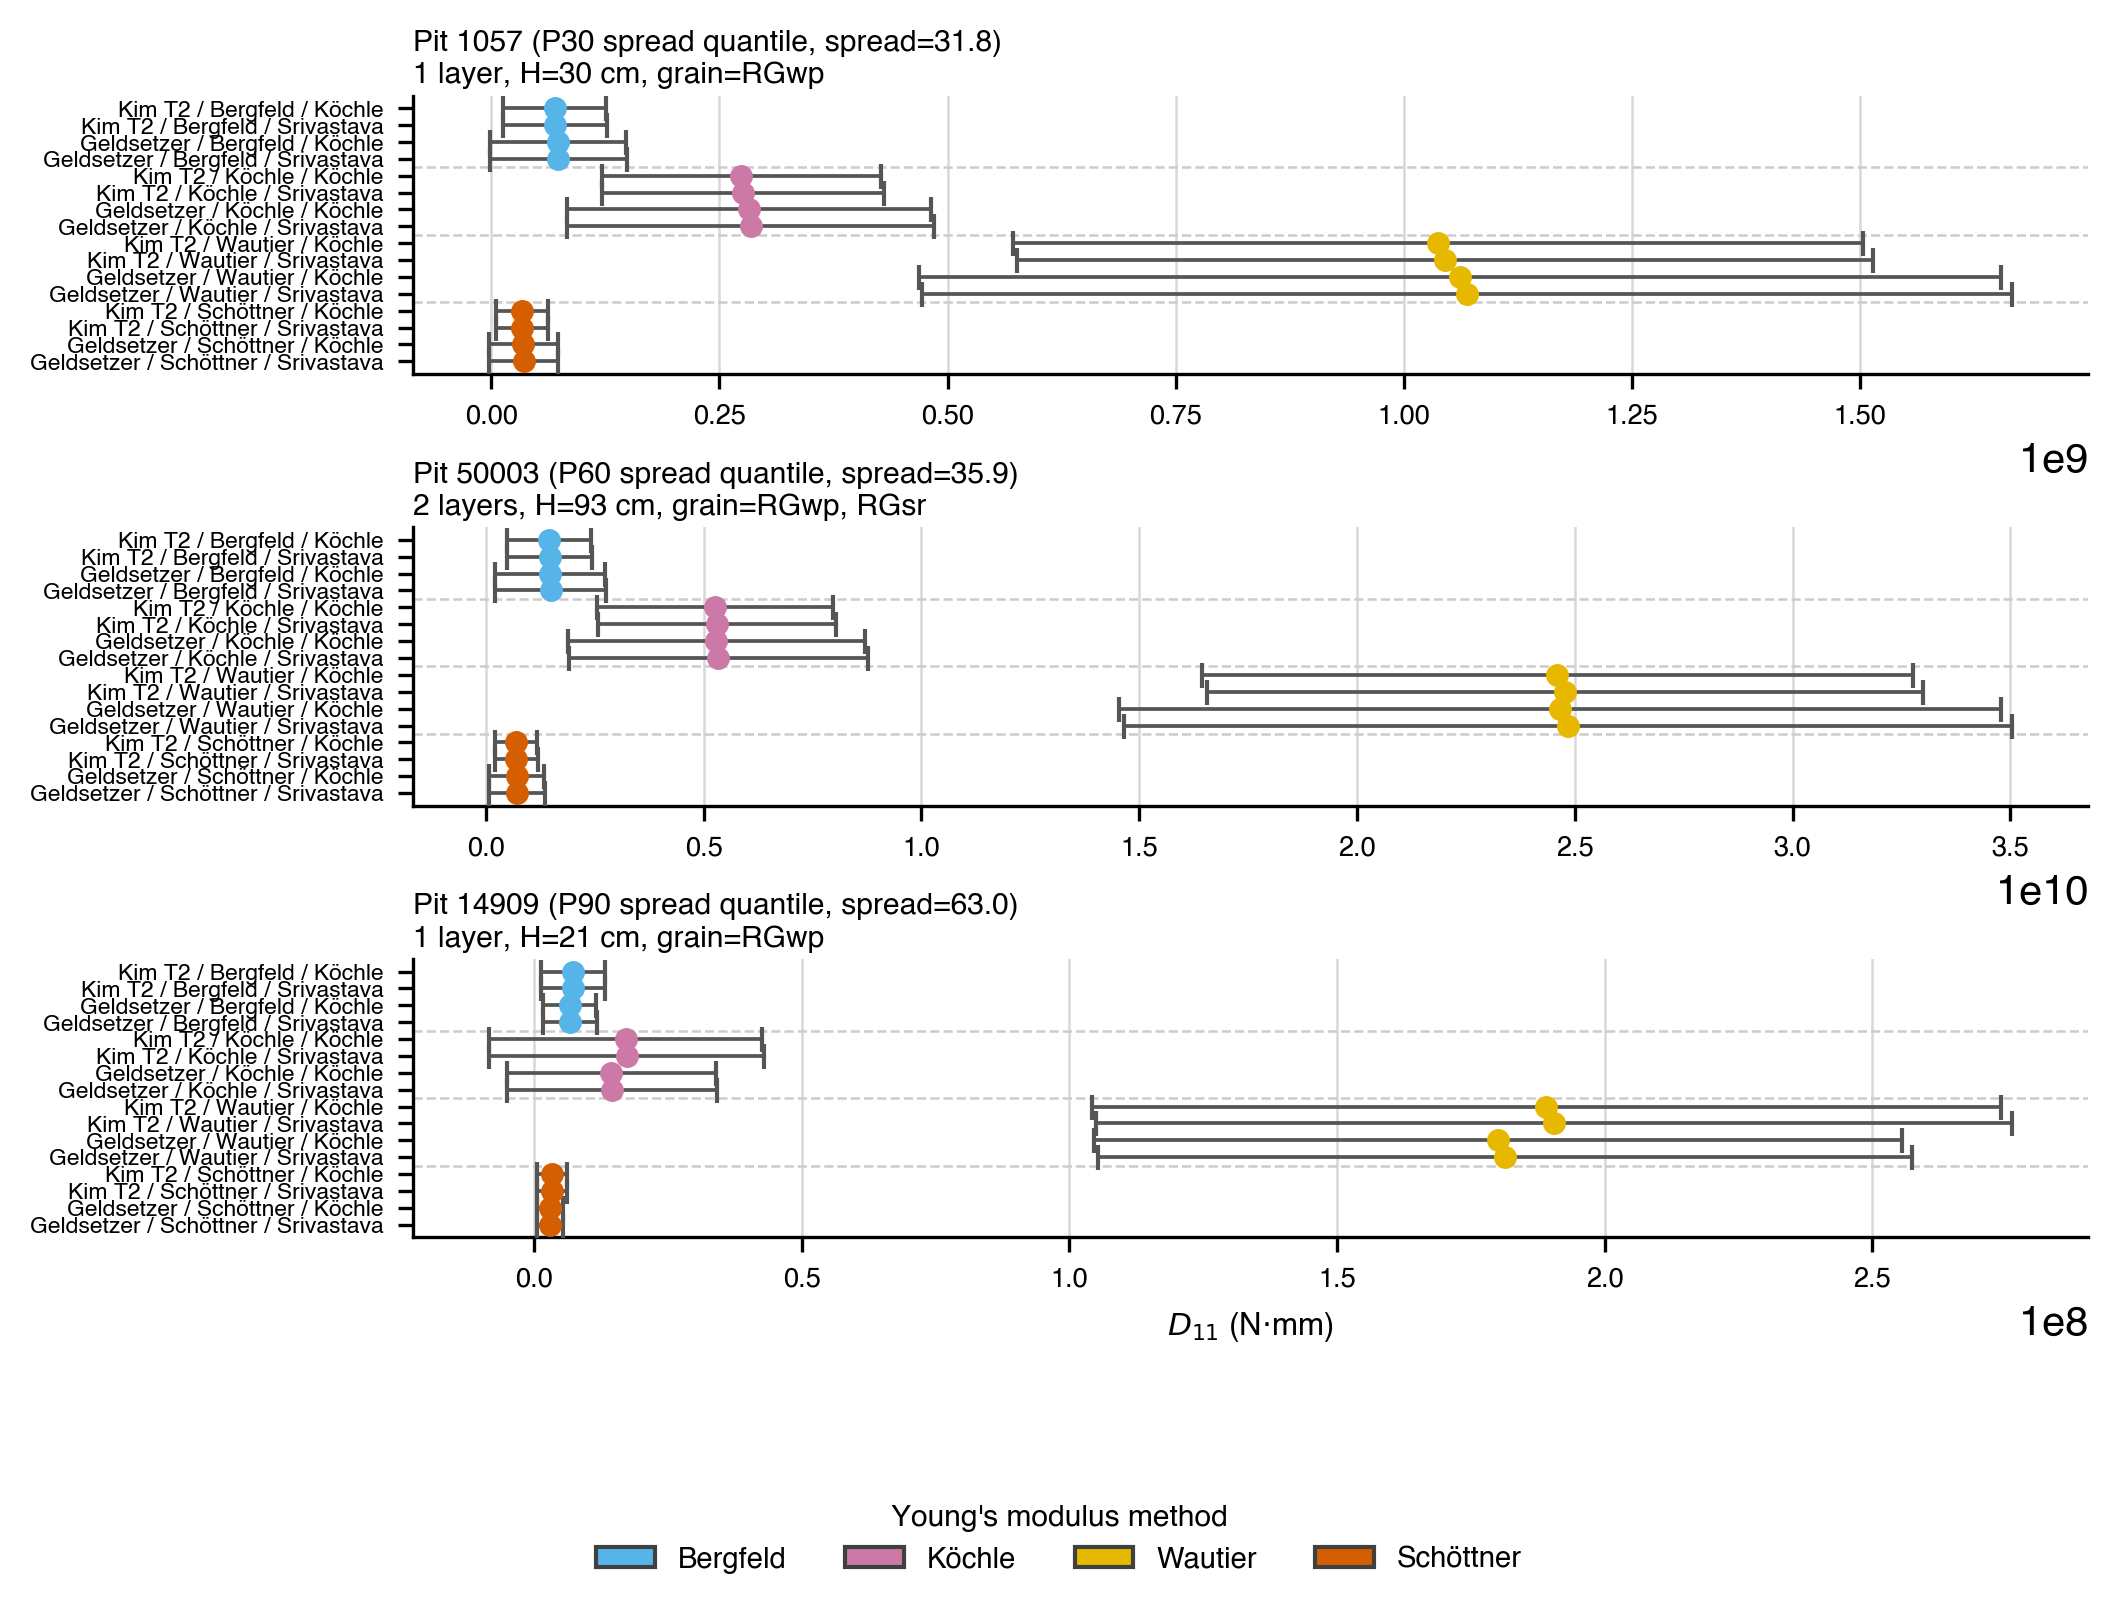

In [8]:
fig_c = build_d11_quantile_slab_uncertainty_figure(
    d11_common,
    selected_slab_indices,
    sorted_paths,
    quantile_labels=quantile_labels,
    slab_metadata_labels=selected_slab_metadata_labels,
)
save_paper_figure(fig_c, 'd11_slab_uncertainty')
plt.show()

## Summary Statistics for Paper Text

Key numbers for the D11 exemplary analysis subsection.

In [9]:
print('=== D11 Exemplary Analysis Summary ===\n')

print(f'Common slabs (all {TOP_N} pathways succeed): {len(common_slab_indices):,}')
print(f'Pathways compared: {TOP_N}')

print(f'\n--- Spread ratio (max/min D11 across pathways) ---')
print(f'  Median: {slab_spread_df["spread_ratio"].median():.1f}')
print(f'  IQR:    {slab_spread_df["spread_ratio"].quantile(0.25):.1f} – {slab_spread_df["spread_ratio"].quantile(0.75):.1f}')
print(f'  Range:  {slab_spread_df["spread_ratio"].min():.1f} – {slab_spread_df["spread_ratio"].max():.1f}')

rel_unc = d11_common['D11_rel_uncertainty'].dropna()
print(f'\n--- Propagated input-measurement uncertainty ---')
print(f'  Median relative uncertainty: {rel_unc.median():.1%}')
print(f'  IQR:   {rel_unc.quantile(0.25):.1%} – {rel_unc.quantile(0.75):.1%}')

# Ratio of median error-bar size to median between-pathway spread
median_spread = slab_spread_df['spread_ratio'].median()
print(f'\n--- Method-choice vs measurement uncertainty ---')
print(f'  Median spread ratio (method choice): {median_spread:.1f}x')
print(f'  Median relative input uncertainty:    {rel_unc.median():.1%}')
print(f'  → Method choice effect dominates by ~{median_spread / (1 + 2 * rel_unc.median()):.0f}x')

# Young's-modulus group medians of pathway ratio
print(f'\n--- Median pathway ratio by Young\'s-modulus method ---')
for emod in EMOD_METHOD_ORDER:
    emod_rows = paired_effects[paired_effects['emod_method'] == emod]
    if len(emod_rows) > 0:
        print(f'  {emod:12s}: {emod_rows["pathway_ratio"].median():.2f}x median')

=== D11 Exemplary Analysis Summary ===

Common slabs (all 16 pathways succeed): 317
Pathways compared: 16

--- Spread ratio (max/min D11 across pathways) ---
  Median: 31.8
  IQR:    31.8 – 51.6
  Range:  25.7 – 63.0

--- Propagated input-measurement uncertainty ---
  Median relative uncertainty: 78.4%
  IQR:   55.8% – 84.8%

--- Method-choice vs measurement uncertainty ---
  Median spread ratio (method choice): 31.8x
  Median relative input uncertainty:    78.4%
  → Method choice effect dominates by ~12x

--- Median pathway ratio by Young's-modulus method ---
  bergfeld    : 0.42x median
  kochle      : 1.59x median
  wautier     : 6.15x median
  schottner   : 0.20x median
